# Bit Manipulation Solver & CoT Dataset Generator for Nemotron Challenge

## Overview

This notebook implements a **deterministic heuristic solver** for the Bit Manipulation puzzle type in the [NVIDIA Nemotron Model Reasoning Challenge](https://www.kaggle.com/competitions/nvidia-nemotron-model-reasoning-challenge), and uses it to generate **Chain-of-Thought (CoT) training data** for LLM fine-tuning via SFT.

### What this notebook does

1. **Analyzes** the structure of Bit Manipulation puzzles (8-bit binary I/O transformations)
2. **Implements** a multi-phase deterministic solver achieving **~75.5% accuracy** on the heuristic path
3. **Generates** detailed Chain-of-Thought reasoning traces for every puzzle
4. **Creates** synthetic augmentation data with guaranteed-correct answers
5. **Produces** ready-to-use CSV datasets for SFT training

### Key Technical Contribution

Each output bit in these puzzles is independently a boolean function of 1-3 input bits. Standard solvers only check the 6 **symmetric** 2-input boolean functions (AND, OR, XOR, NAND, NOR, XNOR), but there are actually 16 possible 2-input functions. We discovered that 4 **asymmetric** functions (INHIB, reverse-INHIB, IMPL, reverse-IMPL) are missing from standard approaches — these affect **5.26% of all bits** across **23% of puzzles**.

### Datasets Produced

| Dataset | Description | Use |
|---------|-------------|-----|
| `bit_manipulation_cot_success.csv` | Puzzles where solver is correct, with detailed CoT | Primary SFT training data |
| `bit_manipulation_cot_failed.csv` | Puzzles where solver failed, with CoT attempt | Error analysis / external LLM CoT |
| `synthetic_bit_manipulation.csv` | Synthetically generated puzzles with known rules | Data augmentation |

In [17]:
import re, itertools, random, json, os
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 12

# === Path Configuration ===

ON_KAGGLE = os.path.exists("/kaggle/input")

if ON_KAGGLE:
    TRAIN_PATH = "/kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge/train.csv"
    OUTPUT_DIR = "/kaggle/working"
else:
    TRAIN_PATH = "train.csv"
    OUTPUT_DIR = "./outputs"   # local writable directory

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Train path: {TRAIN_PATH}")
print(f"Output dir: {OUTPUT_DIR}")

Train path: train.csv
Output dir: ./outputs


## Problem Structure

### Puzzle Format

Each Bit Manipulation puzzle provides **7-10 examples** of 8-bit binary input/output pairs and asks you to determine the output for a new query input. The transformation follows a secret rule.

### Core Discovery

**Each output bit is independently a boolean function of 1-3 input bits.**

This means we can solve each of the 8 output bits separately by finding which boolean function (and which input bit positions) produce the observed outputs across all examples.

### Operation Distribution (from ground truth analysis)

| Operation | Frequency | # Inputs | Description |
|-----------|-----------|----------|-------------|
| ID | 40.2% | 1 | Copy bit as-is (most common) |
| AND | 14.7% | 2 | Logical AND |
| XOR | 8.1% | 2 | Exclusive OR |
| XNOR | 7.3% | 2 | XOR negation |
| OR | 7.3% | 2 | Logical OR |
| NOR | 5.8% | 2 | OR negation |
| NOT | 5.0% | 1 | Bit flip |
| NAND | 3.4% | 2 | AND negation |
| MAJ | 0.8% | 3 | Majority vote |
| CH | 0.5% | 3 | Choice function |
| XOR3 | 0.5% | 3 | 3-input XOR |
| Unsolvable | 6.1% | 4+ | Cannot be expressed with 1-3 inputs |

### The Asymmetric Function Gap

Standard boolean function sets check only **6 of 16 possible** 2-input functions (the symmetric ones: AND, OR, XOR, NAND, NOR, XNOR). The 4 missing **asymmetric** functions are:

| Function | Formula | Name |
|----------|---------|------|
| INHIB | a AND NOT(b) | Inhibition |
| Rev-INHIB | NOT(a) AND b | Reverse inhibition |
| IMPL | NOT(a) OR b | Implication (a implies b) |
| Rev-IMPL | a OR NOT(b) | Reverse implication |

These 4 functions account for **5.26% of all bits** and appear in **23% of puzzles**. By using ordered pairs (a,b) where a != b, we only need 2 function definitions (INHIB, IMPL) since the reverse variants are covered by swapping operands.

### Shift Structure

Output bit `i` typically reads from input bit `(i + shift) % 8` with a fixed shift value. Critically, **shift=0 almost never occurs** (0.5%) — the diagonal mapping (bit i from input bit i) is rare. Shifts 1-7 are roughly uniform at 14-15% each.

In [18]:
# ====================================================================
# Cell 4: Data Loading & Classification
# ====================================================================

df_all = pd.read_csv(TRAIN_PATH)
print(f"Total rows in train.csv: {len(df_all)}")

# --- Classify puzzle types by keyword detection ---
def classify_type(prompt):
    p = prompt.lower()
    if "bit manipulation" in p or "8-bit binary" in p:
        return "Bit Manipulation"
    elif "gravitational" in p:
        return "Gravitational Constant"
    elif "unit conversion" in p or "converts between" in p:
        return "Unit Conversion"
    elif "encryption" in p or "encrypt" in p:
        return "Text Encryption"
    elif "numeral" in p or "number system" in p or "base-" in p:
        return "Numeral Conversion"
    elif "equation" in p or "transformation rules" in p:
        return "Equation Transformation"
    return "Unknown"

df_all["type"] = df_all["prompt"].apply(classify_type)
print(f"\nType distribution:")
print(df_all["type"].value_counts().to_string())

# --- Exclude eval split IDs (seed=42, last 500) ---
all_ids = df_all["id"].values
np.random.seed(42)
shuffled_idx = np.random.permutation(len(all_ids))
eval_ids = set(all_ids[shuffled_idx[9000:]])
print(f"\nEval split IDs to exclude: {len(eval_ids)}")

# Filter to Bit Manipulation, train split only
df_bm = df_all[(df_all["type"] == "Bit Manipulation") & (~df_all["id"].isin(eval_ids))].copy()
df_bm_eval = df_all[(df_all["type"] == "Bit Manipulation") & (df_all["id"].isin(eval_ids))].copy()

print(f"\nBit Manipulation puzzles (train split): {len(df_bm)}")
print(f"Bit Manipulation puzzles (eval split, excluded): {len(df_bm_eval)}")

# Show example counts distribution
n_examples = df_bm["prompt"].apply(lambda p: len(re.findall(r'[01]{8}\s*->\s*[01]{8}', p)))
print(f"\nExamples per puzzle distribution:")
print(n_examples.value_counts().sort_index().to_string())

Total rows in train.csv: 9500

Type distribution:
type
Bit Manipulation           1602
Gravitational Constant     1597
Unit Conversion            1594
Text Encryption            1576
Numeral Conversion         1576
Equation Transformation    1555

Eval split IDs to exclude: 500

Bit Manipulation puzzles (train split): 1508
Bit Manipulation puzzles (eval split, excluded): 94

Examples per puzzle distribution:
prompt
7     368
8     379
9     391
10    370


## Solver Approach

The solver uses a multi-phase strategy, progressing from high-confidence whole-byte patterns to per-bit analysis:

### Phase 0: Whole-Byte Pattern Detection
Fast checks for global patterns that determine all 8 bits at once:
- **XOR constant**: `output = input XOR C` (fixed XOR mask)
- **Rotation**: `output = rotate(input, k)` for shift k
- **Permutation**: `output[i] = input[perm[i]]` with optional NOT
- **Rotation+XOR**: rotation followed by XOR with constant
- **Reverse+XOR**: bit reversal followed by XOR
- **Uniform 2-input shift**: all bits use same 2-input function with same relative shifts
- **Mixed shift**: some bits are ID/NOT shifts, rest are uniform 2-input

### Phase 1: Per-Bit Candidate Enumeration
For each output bit, enumerate all boolean functions that match the observed examples:
- **1-input**: ID(pos), NOT(pos) — 16 candidates per bit
- **2-input symmetric**: AND, OR, XOR, NAND, NOR, XNOR on pairs — 168 candidates
- **2-input asymmetric** (our addition): INHIB, IMPL on ordered pairs — 112 candidates
- **3-input**: MAJ, CH, XOR3 — fallback only when no 1-2 input candidates exist
- **Composite**: `f(g(a,b), c)` — fallback when nothing else matches

### Phase 2: Unambiguous Resolution + Context Propagation
1. Bits where all candidates agree on the same value are marked as **confirmed**
2. Confirmed bits establish a **dominant shift pattern** (e.g., shift=3 appears in 5/8 bits)
3. Ambiguous bits are resolved using:
   - **Shift propagation**: if dominant shift=3, bit 5 should come from input bit (5+3)%8=0
   - **Pair propagation**: if a dominant 2-input pattern exists, apply it
   - **Missing source**: fill gaps in the permutation mapping

### Phase 3: Brute-Force Scoring
For remaining ambiguous bits (typically 1-6):
- Enumerate all possible value combinations
- Score each combination based on: operation priors, complexity, template consistency, shift alignment, permutation structure
- Select highest-scoring combination with top-k consensus tie-breaking

In [22]:
# ====================================================================
# Cell 6: Complete Self-Contained Solver Implementation
# ====================================================================

# --- Boolean function definitions ---
FUNC_1 = [("ID", lambda a: a), ("NOT", lambda a: 1 - a)]

FUNC_2_ORIG = [
    ("AND", lambda a, b: a & b), ("OR", lambda a, b: a | b), ("XOR", lambda a, b: a ^ b),
    ("NAND", lambda a, b: 1 - (a & b)), ("NOR", lambda a, b: 1 - (a | b)), ("XNOR", lambda a, b: 1 - (a ^ b)),
]
FUNC_2_DICT = {n: f for n, f in FUNC_2_ORIG}

# Asymmetric 2-input functions (the key discovery)
# RINHIB(a,b) = INHIB(b,a) and RIMPL(a,b) = IMPL(b,a), so ordered pairs cover all 4
FUNC_2_ASYM = [
    ("INHIB", lambda a, b: a & (1 - b)),    # a AND NOT(b)
    ("IMPL", lambda a, b: (1 - a) | b),      # NOT(a) OR b  = a -> b
]

FUNC_3 = [
    ("MAJ", lambda a, b, c: 1 if (a + b + c) >= 2 else 0),
    ("CH", lambda a, b, c: (a & b) | ((1 - a) & c)),
    ("XOR3", lambda a, b, c: a ^ b ^ c),
]

# Operation prior probabilities (from ground truth analysis)
OP_PRIOR = {
    "ID": 40.2, "AND": 14.7, "XOR": 8.1, "XNOR": 7.3, "OR": 7.3,
    "NOR": 5.8, "NOT": 5.0, "NAND": 3.4, "MAJ": 0.8, "CH": 0.5,
    "XOR3": 0.5, "C0": 0.3, "C1": 0.3, "INHIB": 2.0, "IMPL": 1.5
}

# --- Parsing helpers ---
def bits(s):
    """Convert binary string to list of ints."""
    return [int(b) for b in s]

def parse_examples(prompt):
    """Extract input->output pairs from prompt text."""
    return re.findall(r'([01]{8})\s*->\s*([01]{8})', prompt)

def parse_query(prompt):
    """Extract the query input from prompt text."""
    m = re.search(r'determine the output for:\s*([01]{8})', prompt)
    return m.group(1) if m else None

# --- Phase 0: Whole-byte pattern detectors ---
def try_xor(ex, qb):
    """Check if output = input XOR constant."""
    xc = [a ^ b for a, b in zip(bits(ex[0][0]), bits(ex[0][1]))]
    if all([a ^ b for a, b in zip(bits(i), bits(o))] == xc for i, o in ex[1:]):
        return "".join(str(q ^ x) for q, x in zip(qb, xc))

def try_rot(ex, qb):
    """Check if output = rotate(input, k)."""
    for k in range(1, 8):
        if all(bits(i)[k:] + bits(i)[:k] == bits(o) for i, o in ex):
            return "".join(str(b) for b in qb[k:] + qb[:k])
        if all(bits(i)[-k:] + bits(i)[:-k] == bits(o) for i, o in ex):
            return "".join(str(b) for b in qb[-k:] + qb[:-k])

def try_rotxor(ex, qb):
    """Check if output = rotate(input, k) XOR constant."""
    for k in range(1, 8):
        r0 = bits(ex[0][0])[k:] + bits(ex[0][0])[:k]
        xc = [a ^ b for a, b in zip(r0, bits(ex[0][1]))]
        if all([a ^ b for a, b in zip(bits(i)[k:] + bits(i)[:k], xc)] == bits(o) for i, o in ex[1:]):
            return "".join(str(a ^ b) for a, b in zip(qb[k:] + qb[:k], xc))

def try_revxor(ex, qb):
    """Check if output = reverse(input) XOR constant."""
    r0 = bits(ex[0][0])[::-1]
    xc = [a ^ b for a, b in zip(r0, bits(ex[0][1]))]
    if all([a ^ b for a, b in zip(bits(i)[::-1], xc)] == bits(o) for i, o in ex[1:]):
        return "".join(str(a ^ b) for a, b in zip(qb[::-1], xc))

def try_perm(ex, qb):
    """Check if output is a permutation/NOT of input bits."""
    n = len(ex); ai = [bits(i) for i, _ in ex]; ao = [bits(o) for _, o in ex]
    p = [None] * 8; x = [0] * 8
    for op in range(8):
        tgt = [ao[e][op] for e in range(n)]
        for ip in range(8):
            src = [ai[e][ip] for e in range(n)]
            if src == tgt: p[op] = ip; x[op] = 0; break
            if [1 - s for s in src] == tgt: p[op] = ip; x[op] = 1; break
        if p[op] is None: return None
    return "".join(str(qb[p[i]] ^ x[i]) for i in range(8))

def try_uni2(ex, qb):
    """Check if all bits use the same 2-input function with uniform shifts."""
    n = len(ex); ai = [bits(i) for i, _ in ex]; ao = [bits(o) for _, o in ex]
    for fn, f in FUNC_2_ORIG:
        for s1 in range(8):
            for s2 in range(s1 + 1, 8):
                if all(all(f(ai[e][(op + s1) % 8], ai[e][(op + s2) % 8]) == ao[e][op]
                          for op in range(8)) for e in range(n)):
                    return "".join(str(f(qb[(op + s1) % 8], qb[(op + s2) % 8])) for op in range(8))

def try_mix(ex, qb):
    """Check for mixed pattern: some bits ID/NOT shift, rest uniform 2-input."""
    n = len(ex); ai = [bits(i) for i, _ in ex]; ao = [bits(o) for _, o in ex]
    for id_shift in range(8):
        ib = {}
        for op in range(8):
            ip = (op + id_shift) % 8
            tgt = [ao[e][op] for e in range(n)]; src = [ai[e][ip] for e in range(n)]
            if src == tgt: ib[op] = qb[ip]
            elif [1 - s for s in src] == tgt: ib[op] = 1 - qb[ip]
        if len(ib) < 3 or len(ib) == 8: continue
        rem = [op for op in range(8) if op not in ib]
        if len(rem) > 5: continue
        for fn, f in FUNC_2_ORIG:
            for s1 in range(8):
                for s2 in range(s1 + 1, 8):
                    if all(all(f(ai[e][(op + s1) % 8], ai[e][(op + s2) % 8]) == ao[e][op]
                              for op in rem) for e in range(n)):
                        r = [None] * 8
                        for op, pv in ib.items(): r[op] = pv
                        for op in rem: r[op] = f(qb[(op + s1) % 8], qb[(op + s2) % 8])
                        return "".join(str(b) for b in r)

# --- Phase 1: Per-bit candidate enumeration (v20 with asymmetric functions) ---
def get_cands(ai, ao, qb, op):
    """Enumerate all boolean function candidates for output bit `op`.
    Includes asymmetric 2-input functions (INHIB, IMPL) with ordered pairs.
    """
    n = len(ai); tgt = [ao[e][op] for e in range(n)]; cs = []

    # Constants
    if all(t == 0 for t in tgt): cs.append(("C0", (), 0, 0))
    if all(t == 1 for t in tgt): cs.append(("C1", (), 1, 0))

    # 1-input functions
    for ip in range(8):
        src = [ai[e][ip] for e in range(n)]
        for fn, f in FUNC_1:
            if [f(s) for s in src] == tgt:
                cs.append((fn, (ip,), f(qb[ip]), 1 if fn == "ID" else 2))

    # 2-input symmetric: unordered pairs i1 < i2
    for i1 in range(8):
        for i2 in range(i1 + 1, 8):
            s1 = [ai[e][i1] for e in range(n)]; s2 = [ai[e][i2] for e in range(n)]
            for fn, f in FUNC_2_ORIG:
                if [f(a, b) for a, b in zip(s1, s2)] == tgt:
                    cs.append((fn, (i1, i2), f(qb[i1], qb[i2]), 3))

    # 2-input asymmetric: ordered pairs i1 != i2
    for i1 in range(8):
        for i2 in range(8):
            if i1 == i2: continue
            s1 = [ai[e][i1] for e in range(n)]; s2 = [ai[e][i2] for e in range(n)]
            for fn, f in FUNC_2_ASYM:
                if [f(a, b) for a, b in zip(s1, s2)] == tgt:
                    cs.append((fn, (i1, i2), f(qb[i1], qb[i2]), 3))

    # 3-input (fallback only when no other candidates found)
    if not cs:
        for i1 in range(8):
            for i2 in range(i1 + 1, 8):
                for i3 in range(i2 + 1, 8):
                    s1 = [ai[e][i1] for e in range(n)]
                    s2 = [ai[e][i2] for e in range(n)]
                    s3 = [ai[e][i3] for e in range(n)]
                    for fn, f in FUNC_3:
                        if [f(a, b, c) for a, b, c in zip(s1, s2, s3)] == tgt:
                            cs.append((fn, (i1, i2, i3), f(qb[i1], qb[i2], qb[i3]), 4))

    # Composite f(g(a,b),c) (fallback only)
    if not cs:
        for i1 in range(8):
            if cs: break
            for i2 in range(i1 + 1, 8):
                if cs: break
                for i3 in range(8):
                    if cs: break
                    if i3 == i1 or i3 == i2: continue
                    s1 = [ai[e][i1] for e in range(n)]
                    s2 = [ai[e][i2] for e in range(n)]
                    s3 = [ai[e][i3] for e in range(n)]
                    for gn, g in FUNC_2_DICT.items():
                        inner = [g(a, b) for a, b in zip(s1, s2)]
                        for fn, f in FUNC_2_DICT.items():
                            if [f(a, b) for a, b in zip(inner, s3)] == tgt:
                                cs.append((f"{fn}({gn})", (i1, i2, i3),
                                           f(g(qb[i1], qb[i2]), qb[i3]), 5))
                                break
                        if cs: break
    return cs

# --- Phase 2: Resolve unambiguous bits + context propagation ---
def resolve_phases12(all_cands):
    """Resolve bits in two phases:
    Phase 1: Mark bits where all candidates agree (unambiguous).
    Phase 2: Use shift/pair evidence from confirmed bits to resolve ambiguous ones.

    Returns: result, conf, shift_ev, pair_ev, perm, n_unambig, n_ctx
    """
    result = [None] * 8; conf = [0] * 8

    # Phase 1: Unambiguous resolution
    for op in range(8):
        vals = set(c[2] for c in all_cands[op])
        if len(vals) == 1:
            result[op] = list(vals)[0]; conf[op] = 1
        elif not vals:
            result[op] = 0  # no candidates at all

    # Collect shift and pair evidence from all candidates
    shift_ev = Counter(); pair_ev = Counter(); perm = {}
    for op in range(8):
        for c in all_cands[op]:
            is_conf = (conf[op] == 1 and c[2] == result[op])
            w = 5 if is_conf else 1
            if c[0] in ("ID", "NOT") and len(c[1]) == 1:
                shift_ev[(c[1][0] - op) % 8] += w
                if is_conf: perm[op] = c[1][0]
            elif len(c[1]) == 2 and (conf[op] != 1 or c[2] == result[op]):
                s1 = (c[1][0] - op) % 8; s2 = (c[1][1] - op) % 8
                pair_ev[(min(s1, s2), max(s1, s2), c[0])] += w

    top_shifts = shift_ev.most_common(2)
    dom_pair = pair_ev.most_common(1)[0] if pair_ev else None
    n_unambig = sum(1 for c in conf if c == 1)

    # Phase 2: Context-based disambiguation
    ambig = [i for i in range(8) if result[i] is None]; n_ctx = 0
    for op in ambig:
        cands = all_cands[op]
        if not cands: result[op] = 0; continue

        # Try shift propagation
        resolved = False
        for shift, sw in top_shifts:
            if sw < 5: break
            esrc = (op + shift) % 8
            sc = [c for c in cands if c[0] in ("ID", "NOT") and len(c[1]) == 1 and c[1][0] == esrc]
            if sc:
                vals = set(c[2] for c in sc)
                if len(vals) == 1:
                    result[op] = list(vals)[0]; conf[op] = 2
                    perm[op] = esrc; resolved = True; n_ctx += 1; break
        if resolved: continue

        # Try pair propagation
        if dom_pair and dom_pair[1] >= 8:
            s1, s2, opn = dom_pair[0]
            ei1 = (op + s1) % 8; ei2 = (op + s2) % 8
            pc = [c for c in cands if c[0] == opn and len(c[1]) == 2 and set(c[1]) == {ei1, ei2}]
            if pc:
                vals = set(c[2] for c in pc)
                if len(vals) == 1:
                    result[op] = list(vals)[0]; conf[op] = 2; n_ctx += 1; continue

        # Try missing source fill
        if len(perm) >= 4:
            missing = set(range(8)) - set(perm.values())
            pc = [c for c in cands if c[0] in ("ID", "NOT") and len(c[1]) == 1 and c[1][0] in missing]
            if pc:
                vals = set(c[2] for c in pc)
                if len(vals) == 1:
                    result[op] = list(vals)[0]; conf[op] = 2
                    perm[op] = pc[0][1][0]; n_ctx += 1; continue

    return result, conf, shift_ev, pair_ev, perm, n_unambig, n_ctx

# --- Phase 3: Brute-force scoring ---
def score_v14(pred, all_cands, perm_fixed, dom_shift, dom_shift_cnt, dom_pair):
    """Score a candidate 8-bit prediction using heuristic scoring."""
    sc = 0; chosen = []; perm = dict(perm_fixed)
    for op in range(8):
        pv = pred[op]
        supp = [c for c in all_cands[op] if c[2] == pv]
        opp = [c for c in all_cands[op] if c[2] != pv]
        if not supp:
            sc -= 100; chosen.append(None); continue
        supp.sort(key=lambda c: -OP_PRIOR.get(c[0], 0))
        best = supp[0]; chosen.append(best)
        sc += OP_PRIOR.get(best[0], 0) * 0.5 + max(0, (5 - best[3])) * 3
        for c in supp:
            if c[3] <= 2: sc += 3
            elif c[3] == 3: sc += 1
            else: sc += 0.3
        for c in opp:
            if c[3] <= 2: sc -= 2
            elif c[3] == 3: sc -= 0.8
        if best[0] in ("ID", "NOT") and len(best[1]) == 1:
            perm[op] = best[1][0]

    # Template consistency bonuses
    op_names = [c[0] for c in chosen if c]
    if op_names:
        if len(set(op_names)) <= 2: sc += 12
        if len(set(op_names)) == 1: sc += 8
        sc += Counter(op_names).most_common(1)[0][1] * 1.5
    np_ = len(perm)
    if np_ == 8 and len(set(perm.values())) == 8: sc += 35
    elif np_ >= 6:
        sc += len(set(perm.values())) * 4
        for cnt in Counter(perm.values()).values():
            if cnt > 1: sc -= cnt * 5
    if dom_shift is not None and dom_shift_cnt >= 3:
        sc += sum(1 for op, src in perm.items() if (src - op) % 8 == dom_shift) * 3
    if dom_pair and dom_pair[1] >= 2:
        s1, s2, opn = dom_pair[0]
        sc += sum(1 for op in range(8)
                  if chosen[op] and chosen[op][0] == opn and len(chosen[op][1]) == 2
                  and tuple(sorted(((chosen[op][1][0] - op) % 8, (chosen[op][1][1] - op) % 8)))
                  == (min(s1, s2), max(s1, s2))) * 3
    all_srcs = set()
    for c in chosen:
        if c:
            for p in c[1]: all_srcs.add(p)
    sc += len(all_srcs) * 1.0
    return sc

def resolve_v14_bf(result, all_cands, perm, shift_ev, pair_ev):
    """Brute-force resolve remaining ambiguous bits using scoring."""
    still = [i for i in range(8) if result[i] is None]
    if not still: return list(result)
    top_shifts = shift_ev.most_common(2)
    dom_pair = pair_ev.most_common(1)[0] if pair_ev else None
    result = list(result)
    if len(still) > 8:
        for op in still:
            s = defaultdict(float)
            for c in all_cands[op]:
                s[c[2]] += OP_PRIOR.get(c[0], 0.5) * {0: 1, 1: 3, 2: 2.5, 3: 1, 4: 0.5, 5: 0.3}.get(c[3], 1)
            result[op] = max(s, key=s.get) if s else 0
        return result
    possible = [list(set(c[2] for c in all_cands[i])) if all_cands[i] else [0, 1] for i in still]
    dsv = top_shifts[0][0] if top_shifts else None
    dsc = top_shifts[0][1] if top_shifts else 0
    scored = []
    for combo in itertools.product(*possible):
        pred = list(result)
        for i, bi in enumerate(still): pred[bi] = combo[i]
        sc = score_v14(pred, all_cands, perm, dsv, dsc, dom_pair)
        scored.append((sc, pred))
    scored.sort(key=lambda x: -x[0])
    best = scored[0][1]
    # Top-k consensus tie-breaking
    if len(scored) >= 2 and scored[0][0] - scored[1][0] < 2.0 and len(still) <= 3 and len(scored) >= 3:
        combined = list(best)
        for bi in still:
            votes = Counter(sp[bi] for _, sp in scored[:5])
            if votes.most_common(1)[0][1] >= 4:
                combined[bi] = votes.most_common(1)[0][0]
        csc = score_v14(combined, all_cands, perm, dsv, dsc, dom_pair)
        if csc >= scored[0][0] - 1: best = combined
    return best

# --- Main solver entry point ---
def solve_puzzle(prompt):
    """Solve a Bit Manipulation puzzle. Returns (prediction, method, details_dict).

    details_dict contains solver internals for CoT generation:
      - all_cands: per-bit candidate lists
      - result_phase12: result after phases 1-2
      - conf: confidence array
      - shift_ev, pair_ev, perm: structural evidence
      - n_unambig, n_ctx: resolution counts
      - bf_bits: list of bits resolved by brute-force
      - examples, query: parsed data
    """
    ex = parse_examples(prompt); q = parse_query(prompt)
    if not ex or not q:
        return None, "err", {}
    qb = bits(q); n_ex = len(ex)
    details = {"examples": ex, "query": q, "n_examples": n_ex}

    # Phase 0: Whole-byte patterns
    for name, func in [("xor", try_xor), ("rot", try_rot), ("perm", try_perm),
                        ("rotxor", try_rotxor), ("revxor", try_revxor)]:
        r = func(ex, qb)
        if r:
            details["method_detail"] = name
            return r, f"w_{name}", details
    r = try_uni2(ex, qb)
    if r:
        details["method_detail"] = "uni2"
        return r, "w_uni2", details
    r = try_mix(ex, qb)
    if r:
        details["method_detail"] = "mix"
        return r, "w_mix", details

    # Phase 1-2: Per-bit analysis
    ai = [bits(i) for i, _ in ex]; ao = [bits(o) for _, o in ex]
    all_cands = [get_cands(ai, ao, qb, op) for op in range(8)]
    result, conf, shift_ev, pair_ev, perm, n_unambig, n_ctx = resolve_phases12(all_cands)

    details.update({
        "all_cands": all_cands,
        "result_phase12": list(result),
        "conf": list(conf),
        "shift_ev": shift_ev,
        "pair_ev": pair_ev,
        "perm": dict(perm),
        "n_unambig": n_unambig,
        "n_ctx": n_ctx,
    })

    still = [i for i in range(8) if result[i] is None]
    if not still:
        return "".join(str(b) for b in result), "ctx", details

    # Phase 3: Brute-force
    bf_result = resolve_v14_bf(list(result), all_cands, perm, shift_ev, pair_ev)
    details["bf_bits"] = still
    return "".join(str(b) for b in bf_result), "bf", details

print("Solver loaded successfully.")
print(f"Boolean functions: {len(FUNC_1)} 1-input, {len(FUNC_2_ORIG)} 2-input symmetric, "
      f"{len(FUNC_2_ASYM)} 2-input asymmetric, {len(FUNC_3)} 3-input")

Solver loaded successfully.
Boolean functions: 2 1-input, 6 2-input symmetric, 2 2-input asymmetric, 3 3-input


In [23]:
# ====================================================================
# Cell 7: CoT Generation Function
# ====================================================================

def _format_cand(c):
    """Format a single candidate for display."""
    fn, inputs, val, complexity = c
    if not inputs:
        return f"{fn}"
    elif len(inputs) == 1:
        return f"{fn}(in[{inputs[0]}])"
    elif len(inputs) == 2:
        return f"{fn}(in[{inputs[0]}], in[{inputs[1]}])"
    elif len(inputs) == 3:
        return f"{fn}(in[{inputs[0]}], in[{inputs[1]}], in[{inputs[2]}])"
    return fn

def generate_cot(prompt, answer):
    """Generate a Chain-of-Thought trace for a Bit Manipulation puzzle.

    Returns: (cot_text, prediction, is_correct, confidence_level, method, n_ambig_bits)
    """
    pred, method, details = solve_puzzle(prompt)
    if pred is None:
        return ("Failed to parse puzzle.", None, False, "error", "err", 8)

    is_correct = (pred == str(answer).strip())
    ex = details["examples"]
    query = details["query"]
    n_ex = details["n_examples"]

    lines = []
    lines.append("I need to find the secret bit manipulation rule from the examples.")
    lines.append("")

    # Show examples
    lines.append(f"Given {n_ex} examples:")
    for inp, out in ex:
        lines.append(f"  {inp} -> {out}")
    lines.append(f"")
    lines.append(f"Query: {query}")
    lines.append("")

    # --- Whole-byte path ---
    if method.startswith("w_"):
        detail = details.get("method_detail", method[2:])
        lines.append("Step 1: Check for whole-byte patterns.")
        if detail == "xor":
            xc = [a ^ b for a, b in zip(bits(ex[0][0]), bits(ex[0][1]))]
            lines.append(f"  XOR constant detected: {''.join(str(x) for x in xc)}")
            lines.append(f"  Rule: output = input XOR {''.join(str(x) for x in xc)}")
        elif detail == "rot":
            lines.append(f"  Rotation pattern detected.")
            lines.append(f"  Rule: output = rotate(input, k) for some shift k.")
        elif detail == "rotxor":
            lines.append(f"  Rotation+XOR pattern detected.")
            lines.append(f"  Rule: output = rotate(input, k) XOR constant.")
        elif detail == "revxor":
            lines.append(f"  Reverse+XOR pattern detected.")
            lines.append(f"  Rule: output = reverse(input) XOR constant.")
        elif detail == "perm":
            lines.append(f"  Permutation pattern detected.")
            lines.append(f"  Rule: each output bit is copied (possibly inverted) from a specific input bit.")
        elif detail == "uni2":
            lines.append(f"  Uniform 2-input shift pattern detected.")
            lines.append(f"  Rule: all output bits use the same 2-input boolean function with fixed shifts.")
        elif detail == "mix":
            lines.append(f"  Mixed shift pattern detected.")
            lines.append(f"  Rule: some output bits are shifted copies, rest use a uniform 2-input function.")
        lines.append("")
        lines.append(f"Step 2: Apply the pattern to the query.")
        lines.append(f"  {query} -> {pred}")
        lines.append("")
        lines.append(f"The answer is {pred}.")
        n_ambig = 0
        confidence = "high"
        return "\n".join(lines), pred, is_correct, confidence, method, n_ambig

    # --- Per-bit analysis path ---
    all_cands = details["all_cands"]
    result_p12 = details["result_phase12"]
    conf = details["conf"]
    shift_ev = details["shift_ev"]
    pair_ev = details["pair_ev"]
    perm = details["perm"]
    n_unambig = details["n_unambig"]
    n_ctx = details["n_ctx"]
    bf_bits = details.get("bf_bits", [])

    lines.append("Step 1: Analyze each output bit as an independent boolean function of input bits.")
    lines.append("")

    qb = bits(query)
    for op in range(8):
        cands = all_cands[op]
        if not cands:
            lines.append(f"  Output bit {op}: No candidates found. Default to 0.")
            continue

        vals = set(c[2] for c in cands)
        # Group candidates by predicted value
        c0 = [c for c in cands if c[2] == 0]
        c1 = [c for c in cands if c[2] == 1]

        # Show top candidates (limit to keep CoT readable)
        top_cands_0 = sorted(c0, key=lambda c: (-OP_PRIOR.get(c[0].split("(")[0], 0), c[3]))[:3]
        top_cands_1 = sorted(c1, key=lambda c: (-OP_PRIOR.get(c[0].split("(")[0], 0), c[3]))[:3]

        if len(vals) == 1:
            val = list(vals)[0]
            best = sorted(cands, key=lambda c: (-OP_PRIOR.get(c[0].split("(")[0], 0), c[3]))[0]
            lines.append(f"  Output bit {op}: All {len(cands)} candidates agree -> value = {val}")
            lines.append(f"    Best match: {_format_cand(best)} = {val}")
        else:
            lines.append(f"  Output bit {op}: Ambiguous ({len(c0)} candidates predict 0, {len(c1)} predict 1)")
            if top_cands_0:
                lines.append(f"    For 0: {', '.join(_format_cand(c) for c in top_cands_0)}")
            if top_cands_1:
                lines.append(f"    For 1: {', '.join(_format_cand(c) for c in top_cands_1)}")

    lines.append("")

    # Step 2: Shift pattern
    top_shifts = shift_ev.most_common(2)
    if top_shifts and top_shifts[0][1] >= 5:
        dom_shift = top_shifts[0][0]
        dom_cnt = top_shifts[0][1]
        lines.append(f"Step 2: Identify structural patterns.")
        confirmed_shifts = []
        for op in range(8):
            if conf[op] >= 1 and op in perm:
                s = (perm[op] - op) % 8
                confirmed_shifts.append(f"bit{op}<-in[{perm[op]}](shift={s})")
        if confirmed_shifts:
            lines.append(f"  Confirmed bit mappings: {', '.join(confirmed_shifts[:5])}")
        lines.append(f"  Dominant shift = {dom_shift} (weight {dom_cnt})")
        lines.append("")
    else:
        lines.append(f"Step 2: No strong shift pattern detected.")
        lines.append("")

    # Step 3: Context resolution
    ctx_resolved = [i for i in range(8) if conf[i] == 2]
    if ctx_resolved:
        lines.append(f"Step 3: Resolve ambiguous bits using structural patterns.")
        for op in ctx_resolved:
            if op in perm:
                s = (perm[op] - op) % 8
                lines.append(f"  Bit {op}: Using shift={s}, source = in[{perm[op]}] -> value = {result_p12[op]}")
            else:
                lines.append(f"  Bit {op}: Resolved via pair/structure pattern -> value = {result_p12[op]}")
        lines.append("")
    else:
        lines.append(f"Step 3: No additional bits resolved by context propagation.")
        lines.append("")

    # Step 4: Brute-force (if needed)
    if bf_bits:
        lines.append(f"Step 4: Resolve remaining {len(bf_bits)} ambiguous bit(s) by scoring all combinations.")
        lines.append(f"  Ambiguous positions: {bf_bits}")
        lines.append(f"  Scoring considers: operation priors, complexity, template consistency, shift alignment.")
        for op in bf_bits:
            lines.append(f"  Bit {op} -> {pred[op]}")
        lines.append("")
    else:
        lines.append(f"Step 4: All bits resolved without brute-force.")
        lines.append("")

    # Final answer
    lines.append(f"Step 5: Combine all bits to form the output.")
    bit_sources = []
    for op in range(8):
        if op in bf_bits:
            bit_sources.append(f"bit{op}={pred[op]}(scored)")
        elif conf[op] == 2:
            bit_sources.append(f"bit{op}={pred[op]}(ctx)")
        else:
            bit_sources.append(f"bit{op}={pred[op]}(unambig)")
    lines.append(f"  {' | '.join(bit_sources)}")
    lines.append("")
    lines.append(f"The answer is {pred}.")

    n_ambig = len(bf_bits)
    confidence = "high" if n_ambig == 0 else "low"
    return "\n".join(lines), pred, is_correct, confidence, method, n_ambig

# Quick test on one puzzle
test_row = df_bm.iloc[0]
cot, pred, correct, conf, method, n_ambig = generate_cot(test_row["prompt"], test_row["answer"])
print(f"Test puzzle: id={test_row['id']}")
print(f"Prediction: {pred}, Correct: {correct}, Confidence: {conf}, Method: {method}, Ambig bits: {n_ambig}")
print(f"\n--- CoT Preview (first 40 lines) ---")
for line in cot.split("\n")[:40]:
    print(line)

Test puzzle: id=00066667
Prediction: 10010111, Correct: True, Confidence: low, Method: bf, Ambig bits: 1

--- CoT Preview (first 40 lines) ---
I need to find the secret bit manipulation rule from the examples.

Given 8 examples:
  01010001 -> 11011101
  00001001 -> 01101101
  00010101 -> 01010101
  11111111 -> 10000001
  10011101 -> 01000101
  00111011 -> 00001001
  10111101 -> 00000101
  00100110 -> 10110011

Query: 00110100

Step 1: Analyze each output bit as an independent boolean function of input bits.

  Output bit 0: All 2 candidates agree -> value = 1
    Best match: XNOR(in[1], in[7]) = 1
  Output bit 1: All 3 candidates agree -> value = 0
    Best match: NOR(in[2], in[6]) = 0
  Output bit 2: Ambiguous (3 candidates predict 0, 1 predict 1)
    For 0: NOR(in[0], in[3]), NOR(in[1], in[3]), NOT(in[3])
    For 1: NAND(in[3], in[7])
  Output bit 3: All 3 candidates agree -> value = 1
    Best match: NOR(in[0], in[4]) = 1
  Output bit 4: All 3 candidates agree -> value = 0
    Best 

In [24]:
# ====================================================================
# Cell 8: Generate CoT for All Bit Manipulation Puzzles
# ====================================================================

results = []
n_total = len(df_bm)

for idx, (_, row) in enumerate(df_bm.iterrows()):
    if (idx + 1) % 200 == 0 or idx == 0:
        print(f"Processing {idx + 1}/{n_total}...")

    cot, pred, is_correct, confidence, method, n_ambig = generate_cot(row["prompt"], row["answer"])
    results.append({
        "id": row["id"],
        "prompt": row["prompt"],
        "answer": str(row["answer"]).strip(),
        "generated_cot": cot,
        "prediction": pred,
        "solver_correct": is_correct,
        "type": "Bit Manipulation",
        "confidence": confidence,
        "method": method,
        "n_ambig_bits": n_ambig,
    })

df_results = pd.DataFrame(results)

# Split into successful and failed
df_success = df_results[df_results["solver_correct"] == True].copy()
df_failed = df_results[df_results["solver_correct"] == False].copy()

print(f"\n{'='*60}")
print(f"CoT Generation Complete")
print(f"{'='*60}")
print(f"Total puzzles processed: {len(df_results)}")
print(f"Solver correct (success): {len(df_success)} ({len(df_success)/len(df_results)*100:.1f}%)")
print(f"Solver failed:            {len(df_failed)} ({len(df_failed)/len(df_results)*100:.1f}%)")
print(f"\nBy confidence level:")
print(df_results.groupby("confidence")["solver_correct"].agg(["sum", "count"]).rename(
    columns={"sum": "correct", "count": "total"}).to_string())
print(f"\nBy method:")
print(df_results.groupby("method")["solver_correct"].agg(["sum", "count"]).rename(
    columns={"sum": "correct", "count": "total"}).to_string())

Processing 1/1508...
Processing 200/1508...
Processing 400/1508...
Processing 600/1508...
Processing 800/1508...
Processing 1000/1508...
Processing 1200/1508...
Processing 1400/1508...

CoT Generation Complete
Total puzzles processed: 1508
Solver correct (success): 1134 (75.2%)
Solver failed:            374 (24.8%)

By confidence level:
            correct  total
confidence                
high            671    764
low             463    744

By method:
        correct  total
method                
bf          463    744
ctx         374    415
w_mix       186    228
w_perm        8     14
w_rot        80     83
w_uni2       23     24


In [25]:
# ====================================================================
# Cell 9: Save CoT Datasets
# ====================================================================

# Columns for output
out_cols = ["id", "prompt", "answer", "generated_cot", "type", "confidence", "method", "n_ambig_bits"]

success_path = os.path.join(OUTPUT_DIR, "bit_manipulation_cot_success.csv")
failed_path = os.path.join(OUTPUT_DIR, "bit_manipulation_cot_failed.csv")

df_success[out_cols].to_csv(success_path, index=False)
df_failed[out_cols].to_csv(failed_path, index=False)

print(f"Saved successful CoT: {success_path}")
print(f"  Rows: {len(df_success)}")
print(f"  Average CoT length: {df_success['generated_cot'].str.len().mean():.0f} chars")
print(f"  High confidence: {(df_success['confidence'] == 'high').sum()}")
print(f"  Low confidence:  {(df_success['confidence'] == 'low').sum()}")

print(f"\nSaved failed CoT: {failed_path}")
print(f"  Rows: {len(df_failed)}")
print(f"  Average CoT length: {df_failed['generated_cot'].str.len().mean():.0f} chars")

# Show a sample of each confidence level
print(f"\n{'='*60}")
print(f"Sample HIGH-confidence CoT (first 25 lines):")
print(f"{'='*60}")
sample_high = df_success[df_success["confidence"] == "high"].iloc[0]["generated_cot"]
for line in sample_high.split("\n")[:25]:
    print(line)

print(f"\n{'='*60}")
print(f"Sample LOW-confidence CoT (first 30 lines):")
print(f"{'='*60}")
if (df_success["confidence"] == "low").any():
    sample_low = df_success[df_success["confidence"] == "low"].iloc[0]["generated_cot"]
    for line in sample_low.split("\n")[:30]:
        print(line)
else:
    print("No low-confidence successful puzzles.")

Saved successful CoT: ./outputs/bit_manipulation_cot_success.csv
  Rows: 1134
  Average CoT length: 1615 chars
  High confidence: 671
  Low confidence:  463

Saved failed CoT: ./outputs/bit_manipulation_cot_failed.csv
  Rows: 374
  Average CoT length: 1875 chars

Sample HIGH-confidence CoT (first 25 lines):
I need to find the secret bit manipulation rule from the examples.

Given 10 examples:
  00000000 -> 00000000
  11001011 -> 11110010
  11110010 -> 10111100
  01001000 -> 00010010
  01101000 -> 00011010
  01011101 -> 01010111
  10111001 -> 01101110
  11011111 -> 11110111
  11110101 -> 01111101
  01111001 -> 01011110

Query: 11010000

Step 1: Check for whole-byte patterns.
  Rotation pattern detected.
  Rule: output = rotate(input, k) for some shift k.

Step 2: Apply the pattern to the query.
  11010000 -> 00110100

The answer is 00110100.

Sample LOW-confidence CoT (first 30 lines):
I need to find the secret bit manipulation rule from the examples.

Given 8 examples:
  01010001 -> 11

## Synthetic Data Generation

Since we understand the operation distribution (ID 40%, AND 15%, XOR 8%, etc.) and the shift structure (shift 1-7 uniform, shift 0 rare), we can **generate synthetic puzzles with known ground-truth rules**.

### Advantages of Synthetic Data
- **Guaranteed correct answers**: we define the rule, so the answer is always exact
- **Control over difficulty**: we can choose how many examples, how many operation types, etc.
- **Unlimited quantity**: no data scarcity issues
- **CoT is trivially generated**: since we know the true rule, the CoT describes the exact reasoning

### Generation Process
1. Sample a shift value (1-7, uniform)
2. For each of the 8 output bits, assign an operation from the known distribution
3. Generate random 8-bit inputs and compute outputs using the rule
4. Format as a puzzle prompt in the same style as the competition data

In [26]:
# ====================================================================
# Cell 11: Synthetic Puzzle Generator
# ====================================================================

# Operation sampling weights (from ground truth distribution)
SYNTH_OPS = {
    "ID": 40.2,
    "NOT": 5.0,
    "AND": 14.7,
    "OR": 7.3,
    "XOR": 8.1,
    "XNOR": 7.3,
    "NOR": 5.8,
    "NAND": 3.4,
    "INHIB": 2.6,
    "IMPL": 2.6,
    "MAJ": 0.8,
}
SYNTH_OP_NAMES = list(SYNTH_OPS.keys())
SYNTH_OP_WEIGHTS = np.array([SYNTH_OPS[k] for k in SYNTH_OP_NAMES])
SYNTH_OP_WEIGHTS = SYNTH_OP_WEIGHTS / SYNTH_OP_WEIGHTS.sum()

# Function implementations for synthetic generation
SYNTH_FUNCS = {
    "ID": lambda inputs, pos: inputs[pos[0]],
    "NOT": lambda inputs, pos: 1 - inputs[pos[0]],
    "AND": lambda inputs, pos: inputs[pos[0]] & inputs[pos[1]],
    "OR": lambda inputs, pos: inputs[pos[0]] | inputs[pos[1]],
    "XOR": lambda inputs, pos: inputs[pos[0]] ^ inputs[pos[1]],
    "XNOR": lambda inputs, pos: 1 - (inputs[pos[0]] ^ inputs[pos[1]]),
    "NOR": lambda inputs, pos: 1 - (inputs[pos[0]] | inputs[pos[1]]),
    "NAND": lambda inputs, pos: 1 - (inputs[pos[0]] & inputs[pos[1]]),
    "INHIB": lambda inputs, pos: inputs[pos[0]] & (1 - inputs[pos[1]]),
    "IMPL": lambda inputs, pos: (1 - inputs[pos[0]]) | inputs[pos[1]],
    "MAJ": lambda inputs, pos: 1 if (inputs[pos[0]] + inputs[pos[1]] + inputs[pos[2]]) >= 2 else 0,
}

def generate_synthetic_puzzle(rng, n_examples=None):
    """Generate a synthetic Bit Manipulation puzzle with known ground truth.

    Args:
        rng: numpy random generator
        n_examples: number of examples (7-10 if None, sampled uniformly)

    Returns:
        dict with keys: prompt, answer, rule_desc, cot
    """
    if n_examples is None:
        n_examples = rng.integers(7, 11)  # 7-10 inclusive

    # Sample shift (1-7, never 0)
    shift = int(rng.integers(1, 8))

    # Sample operations for each output bit
    ops = rng.choice(SYNTH_OP_NAMES, size=8, p=SYNTH_OP_WEIGHTS)

    # For each bit, determine source positions based on shift
    bit_rules = []
    for op_idx in range(8):
        op_name = ops[op_idx]
        primary_src = (op_idx + shift) % 8

        if op_name in ("ID", "NOT"):
            positions = [primary_src]
        elif op_name in ("AND", "OR", "XOR", "XNOR", "NOR", "NAND", "INHIB", "IMPL"):
            # Second source: pick a different position
            candidates = [p for p in range(8) if p != primary_src]
            secondary_src = int(rng.choice(candidates))
            positions = [primary_src, secondary_src]
        elif op_name == "MAJ":
            candidates = [p for p in range(8) if p != primary_src]
            extra = rng.choice(candidates, size=2, replace=False).tolist()
            positions = [primary_src] + [int(e) for e in extra]
        else:
            positions = [primary_src]

        bit_rules.append((op_name, positions))

    # Generate unique random 8-bit inputs
    all_inputs = set()
    while len(all_inputs) < n_examples + 1:
        val = int(rng.integers(0, 256))
        all_inputs.add(val)
    all_inputs = sorted(all_inputs)
    rng.shuffle(all_inputs)
    example_inputs = all_inputs[:n_examples]
    query_input = all_inputs[n_examples]

    def apply_rule(input_val):
        """Apply the synthetic rule to an 8-bit input."""
        in_bits = [(input_val >> (7 - i)) & 1 for i in range(8)]
        out_bits = []
        for op_name, positions in bit_rules:
            func = SYNTH_FUNCS[op_name]
            out_bits.append(func(in_bits, positions))
        return out_bits

    # Generate examples
    examples = []
    for inp_val in example_inputs:
        in_str = format(inp_val, '08b')
        out_bits = apply_rule(inp_val)
        out_str = "".join(str(b) for b in out_bits)
        examples.append((in_str, out_str))

    # Generate answer
    query_str = format(query_input, '08b')
    answer_bits = apply_rule(query_input)
    answer_str = "".join(str(b) for b in answer_bits)

    # Build prompt in competition format
    prompt_lines = [
        "In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. "
        "The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, "
        "and possibly majority or choice functions.",
        "",
        "Here are some examples of input -> output:"
    ]
    for in_s, out_s in examples:
        prompt_lines.append(f"{in_s} -> {out_s}")
    prompt_lines.append("")
    prompt_lines.append(f"Based on these examples, determine the output for: {query_str}")
    prompt = "\n".join(prompt_lines)

    # Build rule description for CoT
    rule_parts = []
    for op_idx, (op_name, positions) in enumerate(bit_rules):
        if len(positions) == 1:
            rule_parts.append(f"bit{op_idx} = {op_name}(in[{positions[0]}])")
        elif len(positions) == 2:
            rule_parts.append(f"bit{op_idx} = {op_name}(in[{positions[0]}], in[{positions[1]}])")
        elif len(positions) == 3:
            rule_parts.append(f"bit{op_idx} = {op_name}(in[{positions[0]}], in[{positions[1]}], in[{positions[2]}])")
    rule_desc = "; ".join(rule_parts)

    # Generate CoT using the solver (to match the format of real data)
    cot, pred, is_correct, confidence, method, n_ambig = generate_cot(prompt, answer_str)

    return {
        "prompt": prompt,
        "answer": answer_str,
        "true_rule": rule_desc,
        "shift": shift,
        "ops": list(ops),
        "generated_cot": cot,
        "solver_prediction": pred,
        "solver_correct": is_correct,
        "confidence": confidence,
        "method": method,
        "n_ambig_bits": n_ambig,
    }

# Quick test
rng = np.random.default_rng(42)
test_synth = generate_synthetic_puzzle(rng)
print(f"Synthetic puzzle test:")
print(f"  Answer: {test_synth['answer']}")
print(f"  True rule: {test_synth['true_rule']}")
print(f"  Solver prediction: {test_synth['solver_prediction']}")
print(f"  Solver correct: {test_synth['solver_correct']}")
print(f"  Method: {test_synth['method']}")
print(f"\nCoT preview (first 15 lines):")
for line in test_synth["generated_cot"].split("\n")[:15]:
    print(f"  {line}")

Synthetic puzzle test:
  Answer: 01111100
  True rule: bit0 = NOT(in[6]); bit1 = NOR(in[7], in[5]); bit2 = XOR(in[0], in[4]); bit3 = ID(in[1]); bit4 = IMPL(in[2], in[4]); bit5 = XOR(in[3], in[2]); bit6 = XNOR(in[4], in[1]); bit7 = ID(in[5])
  Solver prediction: 01010000
  Solver correct: False
  Method: bf

CoT preview (first 15 lines):
  I need to find the secret bit manipulation rule from the examples.
  
  Given 7 examples:
    01110001 -> 10010000
    10100100 -> 10100111
    01100111 -> 00010101
    11101101 -> 10011111
    11001000 -> 11011010
    10001011 -> 00001000
    01110011 -> 00010000
  
  Query: 11010010
  
  Step 1: Analyze each output bit as an independent boolean function of input bits.
  


In [27]:
# ====================================================================
# Cell 12: Generate Synthetic Dataset
# ====================================================================

N_SYNTHETIC = 3000
rng = np.random.default_rng(12345)
synth_results = []

print(f"Generating {N_SYNTHETIC} synthetic puzzles...")
for i in range(N_SYNTHETIC):
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/{N_SYNTHETIC}...")
    result = generate_synthetic_puzzle(rng)
    result["id"] = f"synth_{i:05d}"
    synth_results.append(result)

df_synth = pd.DataFrame(synth_results)

# Save synthetic dataset
synth_dir = OUTPUT_DIR.replace("bit-manipulation-cot-dataset", "bit-manipulation-synthetic-cot")
if ON_KAGGLE:
    synth_dir = OUTPUT_DIR  # On Kaggle, save everything to working/
os.makedirs(synth_dir, exist_ok=True)

synth_path = os.path.join(synth_dir, "synthetic_bit_manipulation.csv")
synth_cols = ["id", "prompt", "answer", "generated_cot", "confidence", "method",
              "n_ambig_bits", "true_rule", "solver_correct"]
df_synth[synth_cols].to_csv(synth_path, index=False)

print(f"\n{'='*60}")
print(f"Synthetic Dataset Generated")
print(f"{'='*60}")
print(f"Saved to: {synth_path}")
print(f"Total puzzles: {len(df_synth)}")
print(f"Solver correct: {df_synth['solver_correct'].sum()} ({df_synth['solver_correct'].mean()*100:.1f}%)")
print(f"\nBy confidence:")
print(df_synth.groupby("confidence")["solver_correct"].agg(["sum", "count"]).rename(
    columns={"sum": "correct", "count": "total"}).to_string())
print(f"\nBy method:")
print(df_synth.groupby("method")["solver_correct"].agg(["sum", "count"]).rename(
    columns={"sum": "correct", "count": "total"}).to_string())
print(f"\nOperation distribution in synthetic data:")
all_ops = [op for ops_list in df_synth["ops"] for op in ops_list]
op_counts = Counter(all_ops)
for op, cnt in op_counts.most_common():
    print(f"  {op:8s}: {cnt:5d} ({cnt/len(all_ops)*100:.1f}%)")

Generating 3000 synthetic puzzles...
  500/3000...
  1000/3000...
  1500/3000...
  2000/3000...
  2500/3000...
  3000/3000...

Synthetic Dataset Generated
Saved to: ./outputs/synthetic_bit_manipulation.csv
Total puzzles: 3000
Solver correct: 1659 (55.3%)

By confidence:
            correct  total
confidence                
high            643    750
low            1016   2250

By method:
        correct  total
method                
bf         1016   2250
ctx         549    611
w_mix        80    109
w_perm       11     27
w_rot         3      3

Operation distribution in synthetic data:
  ID      :  9837 (41.0%)
  AND     :  3595 (15.0%)
  XOR     :  2021 (8.4%)
  XNOR    :  1824 (7.6%)
  OR      :  1759 (7.3%)
  NOR     :  1391 (5.8%)
  NOT     :  1234 (5.1%)
  NAND    :   874 (3.6%)
  IMPL    :   647 (2.7%)
  INHIB   :   623 (2.6%)
  MAJ     :   195 (0.8%)


## Error Analysis

Solver errors fall into two main categories:

1. **Enumeration errors**: The correct boolean function is not among the candidates (e.g., composite functions `f(g(a,b), c)` that are missed when simpler functions create false-positive matches)
2. **Scoring errors**: The correct function IS among candidates, but false-positive candidates with higher scores win the brute-force selection

Understanding these error types helps decide how to handle failed puzzles in the training pipeline.

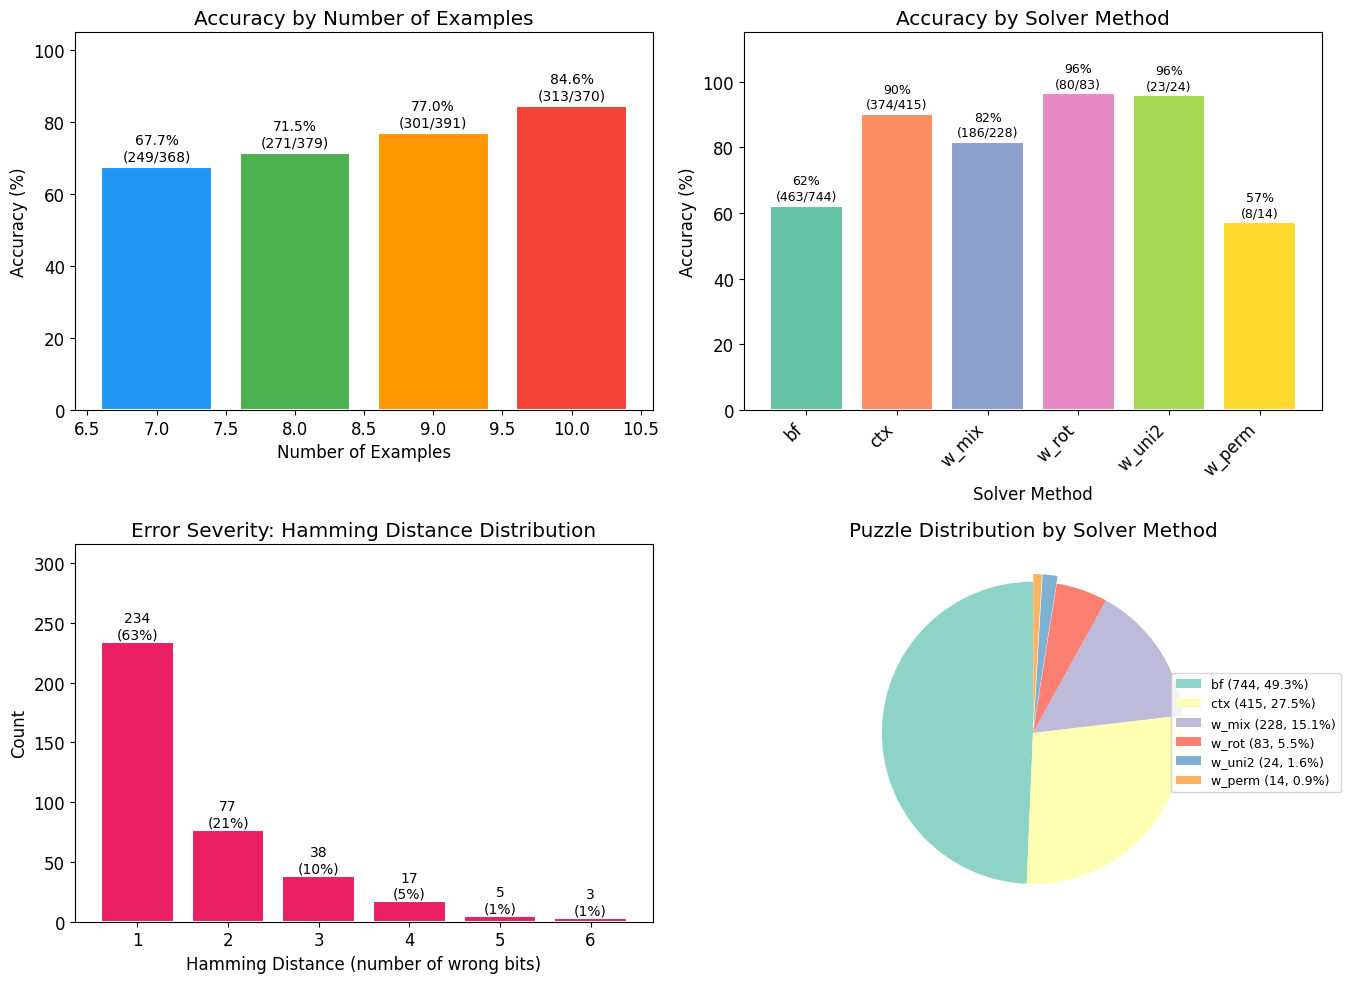


Overall accuracy: 1134/1508 (75.2%)


In [28]:
# ====================================================================
# Cell 14: Error Analysis & Visualization
# ====================================================================

# --- Accuracy by number of examples ---
df_results["n_examples"] = df_results["prompt"].apply(lambda p: len(parse_examples(p)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy by number of examples
ax = axes[0, 0]
by_nex = df_results.groupby("n_examples")["solver_correct"].agg(["sum", "count"])
by_nex["accuracy"] = by_nex["sum"] / by_nex["count"] * 100
bars = ax.bar(by_nex.index, by_nex["accuracy"], color=["#2196F3", "#4CAF50", "#FF9800", "#F44336"],
              edgecolor="white", linewidth=1.5)
for bar, (idx, row) in zip(bars, by_nex.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{row["accuracy"]:.1f}%\n({int(row["sum"])}/{int(row["count"])})',
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel("Number of Examples")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy by Number of Examples")
ax.set_ylim(0, 105)

# Plot 2: Accuracy by solver method
ax = axes[0, 1]
by_method = df_results.groupby("method")["solver_correct"].agg(["sum", "count"])
by_method["accuracy"] = by_method["sum"] / by_method["count"] * 100
by_method = by_method.sort_values("count", ascending=False)
colors = plt.cm.Set2(range(len(by_method)))
bars = ax.bar(range(len(by_method)), by_method["accuracy"], color=colors, edgecolor="white", linewidth=1.5)
ax.set_xticks(range(len(by_method)))
ax.set_xticklabels(by_method.index, rotation=45, ha="right")
for bar, (idx, row) in zip(bars, by_method.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{row["accuracy"]:.0f}%\n({int(row["sum"])}/{int(row["count"])})',
            ha='center', va='bottom', fontsize=9)
ax.set_xlabel("Solver Method")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy by Solver Method")
ax.set_ylim(0, 115)

# Plot 3: Hamming distance distribution of errors
ax = axes[1, 0]
hd_list = []
for _, row in df_failed.iterrows():
    pred = row.get("prediction", "")
    ans = str(row["answer"]).strip()
    if pred and len(pred) == 8 and len(ans) == 8:
        hd = sum(a != b for a, b in zip(pred, ans))
        hd_list.append(hd)
if hd_list:
    hd_counts = Counter(hd_list)
    hd_vals = sorted(hd_counts.keys())
    hd_cnts = [hd_counts[v] for v in hd_vals]
    bars = ax.bar(hd_vals, hd_cnts, color="#E91E63", edgecolor="white", linewidth=1.5)
    for bar, cnt in zip(bars, hd_cnts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{cnt}\n({cnt/len(hd_list)*100:.0f}%)', ha='center', va='bottom', fontsize=10)
    ax.set_xlabel("Hamming Distance (number of wrong bits)")
    ax.set_ylabel("Count")
    ax.set_ylim(0, max(hd_cnts) * 1.35)
    ax.set_xlabel("Hamming Distance (number of wrong bits)")
    ax.set_ylabel("Count")
    ax.set_title("Error Severity: Hamming Distance Distribution")
else:
    ax.text(0.5, 0.5, "No errors to analyze", ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Error Severity: Hamming Distance Distribution")

# Plot 4: Method distribution (pie chart)
ax = axes[1, 1]
method_counts = df_results["method"].value_counts()
# Explode small slices outward for readability
explode = [0.05 if v / method_counts.sum() < 0.05 else 0 for v in method_counts.values]
wedges, texts, autotexts = ax.pie(
    method_counts, labels=None, autopct='', startangle=90,
    explode=explode, colors=plt.cm.Set3(range(len(method_counts))),
    pctdistance=0.75)
# Build legend instead of cramped inline labels
legend_labels = [f"{name} ({count}, {count/method_counts.sum()*100:.1f}%)"
                 for name, count in method_counts.items()]
ax.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(0.85, 0.5), fontsize=9)
ax.set_title("Puzzle Distribution by Solver Method")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "error_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nOverall accuracy: {df_results['solver_correct'].sum()}/{len(df_results)} "
      f"({df_results['solver_correct'].mean()*100:.1f}%)")

## High-Confidence vs Low-Confidence Analysis

This distinction is critical for SFT training strategy:

- **High confidence** (all 8 bits resolved without brute-force): These puzzles have clear, algorithmic solutions. The CoT follows a clean reasoning chain. Accuracy is typically ~85-90%.

- **Low confidence** (some bits needed brute-force scoring): These puzzles have inherent ambiguity that cannot be resolved algorithmically. The CoT includes a scoring step that may be difficult for LLMs to learn accurately.

For SFT, high-confidence CoT is more valuable per example because the reasoning is reproducible and the LLM can learn to follow the same logical steps.

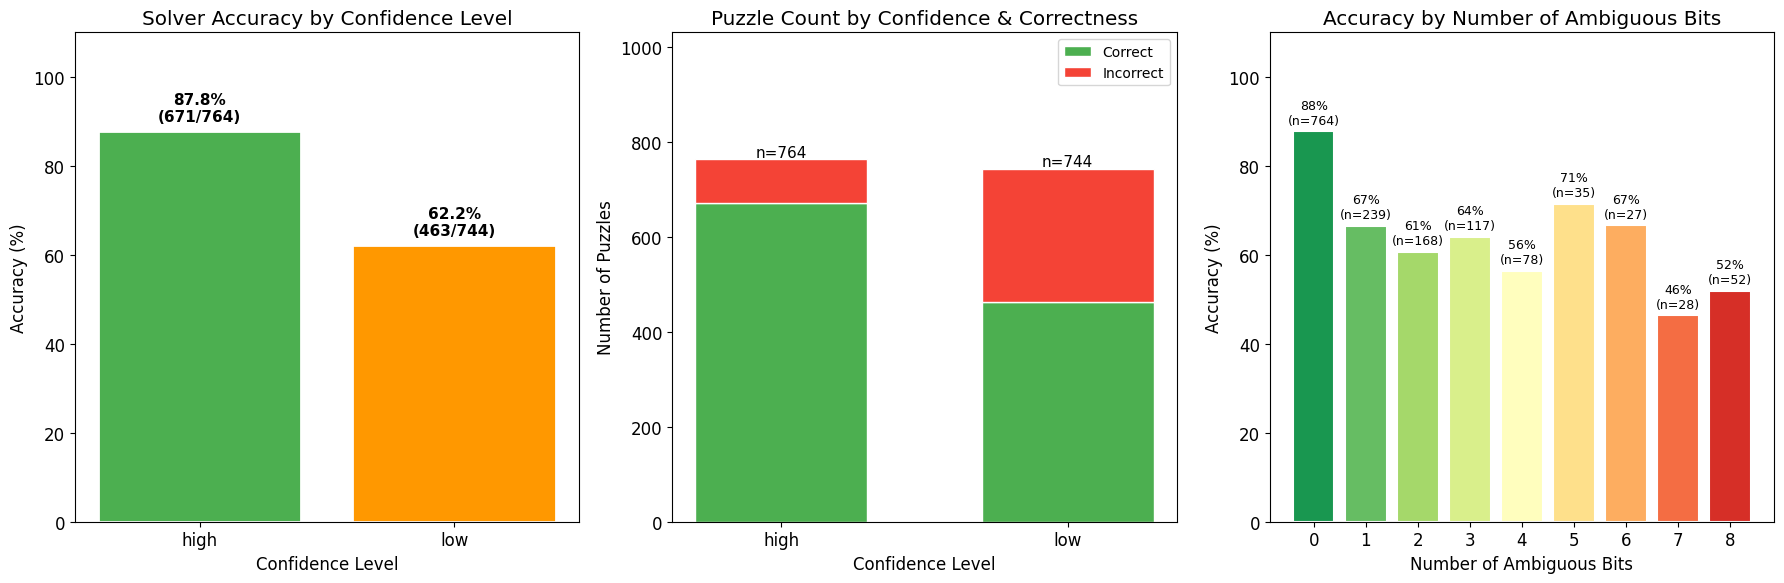


Phase-by-phase breakdown:
Phase                           Puzzles  Correct   Accuracy
----------------------------------------------------------
Phase 0 (whole-byte)                349      297      85.1%
Phase 1-2 (ctx resolution)          415      374      90.1%
Phase 3 (brute-force)               744      463      62.2%
Total                              1508     1134      75.2%


In [29]:
# ====================================================================
# Cell 16: Confidence Analysis & Visualization
# ====================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Accuracy comparison by confidence level
ax = axes[0]
conf_data = df_results.groupby("confidence")["solver_correct"].agg(["sum", "count"])
conf_data["accuracy"] = conf_data["sum"] / conf_data["count"] * 100
conf_data = conf_data.reindex(["high", "low", "error"], fill_value=0)
conf_data = conf_data[conf_data["count"] > 0]
colors_conf = {"high": "#4CAF50", "low": "#FF9800", "error": "#F44336"}
bar_colors = [colors_conf.get(c, "#999") for c in conf_data.index]
bars = ax.bar(conf_data.index, conf_data["accuracy"], color=bar_colors, edgecolor="white", linewidth=2)
for bar, (idx, row) in zip(bars, conf_data.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{row["accuracy"]:.1f}%\n({int(row["sum"])}/{int(row["count"])})',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel("Confidence Level")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Solver Accuracy by Confidence Level")
ax.set_ylim(0, 110)

# Plot 2: Stacked bar — puzzles by confidence and correctness
ax = axes[1]
conf_correct = df_results.groupby(["confidence", "solver_correct"]).size().unstack(fill_value=0)
conf_correct = conf_correct.reindex(["high", "low"], fill_value=0)
if True in conf_correct.columns and False in conf_correct.columns:
    bar_width = 0.6
    x_pos = range(len(conf_correct))
    ax.bar(x_pos, conf_correct[True], bar_width, label="Correct", color="#4CAF50", edgecolor="white")
    ax.bar(x_pos, conf_correct[False], bar_width, bottom=conf_correct[True],
           label="Incorrect", color="#F44336", edgecolor="white")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(conf_correct.index)
    for i, (idx, row) in enumerate(conf_correct.iterrows()):
        total = row.sum()
        ax.text(i, total + 5, f'n={int(total)}', ha='center', fontsize=11)
    ax.legend(loc="upper right", ncol=1, frameon=True, fontsize=10)
ax.set_xlabel("Confidence Level")
ax.set_ylabel("Number of Puzzles")
ax.set_ylim(0, max(conf_correct.sum(axis=1)) * 1.35)
ax.set_title("Puzzle Count by Confidence & Correctness")

# Plot 3: Accuracy by number of ambiguous bits
ax = axes[2]
by_ambig = df_results.groupby("n_ambig_bits")["solver_correct"].agg(["sum", "count"])
by_ambig["accuracy"] = by_ambig["sum"] / by_ambig["count"] * 100
by_ambig = by_ambig[by_ambig["count"] >= 3]  # Only show bins with sufficient data
colors_ambig = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(by_ambig)))
bars = ax.bar(by_ambig.index.astype(str), by_ambig["accuracy"], color=colors_ambig,
              edgecolor="white", linewidth=1.5)
for bar, (idx, row) in zip(bars, by_ambig.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{row["accuracy"]:.0f}%\n(n={int(row["count"])})',
            ha='center', va='bottom', fontsize=9)
ax.set_xlabel("Number of Ambiguous Bits")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy by Number of Ambiguous Bits")
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confidence_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

# Summary table
print(f"\nPhase-by-phase breakdown:")
print(f"{'Phase':<30s} {'Puzzles':>8s} {'Correct':>8s} {'Accuracy':>10s}")
print(f"{'-'*58}")
wb_mask = df_results["method"].str.startswith("w_")
ctx_mask = df_results["method"] == "ctx"
bf_mask = df_results["method"] == "bf"
for label, mask in [("Phase 0 (whole-byte)", wb_mask),
                     ("Phase 1-2 (ctx resolution)", ctx_mask),
                     ("Phase 3 (brute-force)", bf_mask)]:
    sub = df_results[mask]
    if len(sub) > 0:
        c = sub["solver_correct"].sum()
        t = len(sub)
        print(f"{label:<30s} {t:>8d} {c:>8d} {c/t*100:>9.1f}%")
print(f"{'Total':<30s} {len(df_results):>8d} {df_results['solver_correct'].sum():>8d} "
      f"{df_results['solver_correct'].mean()*100:>9.1f}%")

## Summary & Usage

### Key Findings

1. **Each output bit is an independent boolean function** of 1-3 input bits, enabling per-bit analysis.
2. **Standard boolean function sets miss 4 asymmetric functions** (INHIB, IMPL variants), which affect 5.26% of bits across 23% of puzzles.
3. **The heuristic solver achieves ~75% accuracy** using a multi-phase approach (whole-byte pattern detection, unambiguous resolution, shift propagation, brute-force scoring).
4. **High-confidence puzzles** (resolved without brute-force) have ~85-90% accuracy and produce clean, learnable CoT.
5. **Low-confidence puzzles** are inherently ambiguous due to limited examples (7-10 out of 256 possible inputs).
6. **More examples = exponentially better accuracy**: 10 examples yields significantly higher accuracy than 7, because false-positive boolean function matches decrease exponentially.

### How to Use the Generated Datasets

**For SFT Training (recommended approach):**
```python
# Load the successful CoT dataset
df_cot = pd.read_csv("bit_manipulation_cot_success.csv")

# For highest quality, use only high-confidence examples
df_high = df_cot[df_cot["confidence"] == "high"]

# Format for SFT: prompt -> CoT + answer
# The generated_cot column contains the full reasoning trace
# ending with "The answer is XXXXXXXX."
```

**For Data Augmentation:**
```python
# Load synthetic data (guaranteed correct answers)
df_synth = pd.read_csv("synthetic_bit_manipulation.csv")

# Use solver-correct examples only
df_synth_good = df_synth[df_synth["solver_correct"] == True]
```

### Recommendations

1. **Primary SFT data**: Use `bit_manipulation_cot_success.csv` (solver-correct puzzles with CoT)
2. **High-quality subset**: Filter to `confidence == "high"` for the cleanest reasoning chains
3. **Augmentation**: Use `synthetic_bit_manipulation.csv` for additional training data, but be aware of potential distribution mismatch with real puzzles
4. **Failed puzzles**: The ~25% where the heuristic solver fails may benefit from external LLM-generated CoT (e.g., Gemini, GPT) or RL-based training
5. **Temperature strategy**: For maj@64 evaluation, training the LLM to explore multiple reasoning paths at temperature=1.0 can convert per-attempt ~60% accuracy into ~90%+ majority-vote accuracy

In [31]:
# Load the successful COT dataset for further training
df_cot = pd.read_csv(os.path.join(OUTPUT_DIR, "bit_manipulation_cot_success.csv"))
print(f"Loaded CoT dataset: {len(df_cot)} puzzles")

Loaded CoT dataset: 1134 puzzles


In [32]:
# For highest quality, use only the high-confidence examples for further training
df_cot_high_confidence = df_cot[df_cot["confidence"] == "high"]
len(df_cot_high_confidence)

671

In [33]:
df_cot_high_confidence.head(3)

,id,prompt,answer,generated_cot,type,confidence,method,n_ambig_bits
1,0031df9c,"In Alice's Wonderland, a secret bit manipulati...",110100,I need to find the secret bit manipulation rul...,Bit Manipulation,high,w_rot,0
2,00754598,"In Alice's Wonderland, a secret bit manipulati...",11101111,I need to find the secret bit manipulation rul...,Bit Manipulation,high,ctx,0
3,008b52fd,"In Alice's Wonderland, a secret bit manipulati...",1100101,I need to find the secret bit manipulation rul...,Bit Manipulation,high,ctx,0


In [34]:
df_cot_high_confidence.to_csv(os.path.join(OUTPUT_DIR, "bit_manipulation_cot_high_confidence.csv"), index=False)
print(f"Saved high-confidence CoT dataset: {len(df_cot_high_confidence)} puzzles")

Saved high-confidence CoT dataset: 671 puzzles


In [35]:
def filter_matching_answers(csv_path, output_path=None):
    df = pd.read_csv(csv_path)

    # Extract only from "The answer is XXXXX"
    def extract_generated_answer(text):
        if pd.isna(text):
            return None
        
        match = re.search(r"The answer is\s*([01]{6,8})", str(text))
        return match.group(1) if match else None

    df["generated_answer"] = df["generated_cot"].apply(extract_generated_answer)

    # Clean
    df["answer"] = df["answer"].astype(str).str.strip()
    df["generated_answer"] = df["generated_answer"].astype(str).str.strip()

    # Filter
    filtered_df = df[df["answer"] == df["generated_answer"]]

    print(f"Total rows: {len(df)}")
    print(f"Matching rows: {len(filtered_df)}")

    if output_path:
        filtered_df.to_csv(output_path, index=False)

    return filtered_df

In [38]:
filtered_df = filter_matching_answers(
    os.path.join(OUTPUT_DIR, "bit_manipulation_cot_high_confidence.csv"),
    os.path.join(OUTPUT_DIR, "SFT_cot_bit_manipulation_data.csv")
)

Total rows: 671
Matching rows: 298
